# MIDTER EXERCISE

## TASK 1
Consider the joint distribution $p(X, Y)$:


\begin{array}{c|cccc}
& x=1 & x=2 & x=3 & x=4 \\
\hline
y=1 & \frac{1}{4} & \frac{1}{8} & \frac{1}{16} & \frac{1}{8} \\
y=2 & \frac{1}{8} & \frac{1}{4} & \frac{1}{16} & 0 \\
\end{array}

*For all calculations, use Log base e*
1. What is the joint entropy $H(X, Y)$?

2. What are the marginal entropies $H(X)$ and $H(Y)$?

3. Compute $H(X|Y=2)$

4. Compute $H(X|Y)$
   
5. What is the mutual information between $X$ and $Y$: I(X;Y)?

In [4]:
import numpy as np
p_xy = np.array([[1/4, 1/8,1/16,1/8],
                 [1/8, 1/4,1/16,0]])

In [8]:
#JOINT ENTROPY
print("H(X,Y)": -np.nansum(p_xy * np.log( p_xy, where = p_xy!=0 )))

1.8195113489698564

In [14]:
#Marginal Entropy
p_x=p_xy.sum(axis=0)
p_y=p_xy.sum(axis=1)
print("H(X):",-np.nansum(p_x * np.log( p_x, where = p_x!=0 )) )
print("H(Y):",-np.nansum(p_y * np.log( p_y, where = p_y!=0 )) )


H(X): 1.2554823251787537
H(Y): 0.6853142072764582
[0.375 0.375 0.125 0.125]


In [20]:
#Conditional Entropy
p_x_given_y = p_xy / p_y[:, None]
conditional_entropy_2 = -np.nansum(p_x_given_y * np.log(p_x_given_y, where = (p_x_given_y != 0)), axis=1)
print("H(X|Y=2):",conditional_entropy_2[1])

H(X|Y=2): 1.3787834934861753


In [26]:
#Conditional entropy
conditional_entropy = -np.nansum(p_xy * np.log(p_xy), where=p_xy != 0) + np.nansum(p_y * np.log(p_y))
print("H(X|Y):",conditional_entropy )


H(X|Y): 1.1341971416933982


/var/folders/6r/17dbwpxj45s03vzxrc5kddj40000gn/T/ipykernel_93225/192229898.py:2: RuntimeWarning: divide by zero encountered in log
  conditional_entropy = -np.nansum(p_xy * np.log(p_xy), where=p_xy != 0) + np.nansum(p_y * np.log(p_y))
/var/folders/6r/17dbwpxj45s03vzxrc5kddj40000gn/T/ipykernel_93225/192229898.py:2: RuntimeWarning: invalid value encountered in multiply
  conditional_entropy = -np.nansum(p_xy * np.log(p_xy), where=p_xy != 0) + np.nansum(p_y * np.log(p_y))


In [22]:
#Mutual information
H_X = -np.nansum(p_x * np.log( p_x, where = p_x!=0 ))
H_Y = -np.nansum(p_y * np.log( p_y, where = p_y!=0 ))
H_XY = -np.nansum(p_xy * np.log( p_xy, where = p_xy!=0 ))
print("I(X;Y)=", H_X+H_Y-H_XY)

I(X;Y)= 0.12128518348535544


## TASK 2
Now, consider the dataset poisson_glm_dataset.csv with three input variables $X_i$ and an output $Y$. Write a Linear Model that computes an output combining X variables as. 

$ \mu_i = \exp(X \beta) $

Then, the betas of the Linear Model should be optimized so as to mazimize the log-likelihood of the predictions with respect to Y

$$
\log L(\beta) = \sum_{i=1}^{n} \left( \mu_i - y_i \log(\mu_i) \right)
$$
where $ \mu_i = \exp(X_i \beta) $.


Epoch 0, Loss: -965695296.0000
Epoch 10, Loss: -1029099648.0000
Epoch 20, Loss: -1097446016.0000
Epoch 30, Loss: -1171799552.0000
Epoch 40, Loss: -1253251968.0000
Epoch 50, Loss: -1342929920.0000
Epoch 60, Loss: -1442040576.0000
Epoch 70, Loss: -1551931264.0000
Epoch 80, Loss: -1674128512.0000
Epoch 90, Loss: -1810403584.0000
Epoch 100, Loss: -1962815488.0000
Epoch 110, Loss: -2133775616.0000
Epoch 120, Loss: -2326108160.0000
Epoch 130, Loss: -2543153664.0000
Epoch 140, Loss: -2788854528.0000
Epoch 150, Loss: -3067878912.0000
Epoch 160, Loss: -3385779200.0000
Epoch 170, Loss: -3749172480.0000
Epoch 180, Loss: -4165943552.0000
Epoch 190, Loss: -4645592576.0000
Epoch 200, Loss: -5199465984.0000
Epoch 210, Loss: -5841281536.0000
Epoch 220, Loss: -6587580416.0000
Epoch 230, Loss: -7458442240.0000
Epoch 240, Loss: -8478167552.0000
Epoch 250, Loss: -9676370944.0000
Epoch 260, Loss: -11089257472.0000
Epoch 270, Loss: -12761021440.0000
Epoch 280, Loss: -14745913344.0000
Epoch 290, Loss: -17110

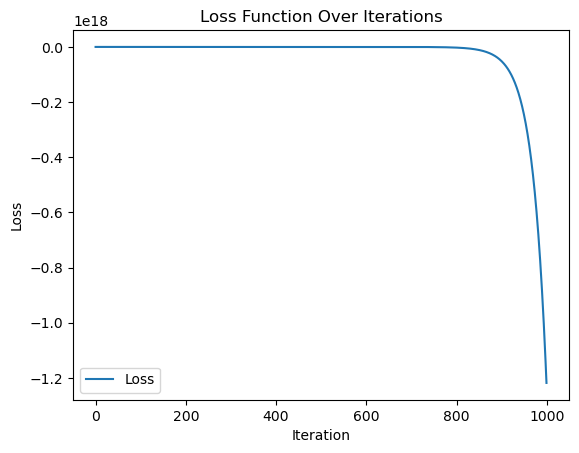

In [124]:
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt, pi, exp

# Cargamos los datos
df = pd.read_csv('poisson_glm_dataset.csv')
X = df.iloc[:, :3].to_numpy()
y = df['y'].to_numpy()

# Convertimos el vector de variables independientes y la variable dependiente en un Tensor de TensorFlow.
X_tf = tf.constant(X, dtype=tf.float32)
y_tf = tf.constant(y, dtype=tf.float32)

# Generate a synthetic binary classification dataset
n_samples = X.shape[0]
n_features = X.shape[1]


# Initialize model parameters (beta coefficients) 
#beta = tf.Variable(tf.random.normal([n_features+1, 1], dtype=tf.float32))
beta = tf.Variable([1.02, 3.60, 3.18, 3.69], dtype=tf.float32)
beta = tf.Variable(tf.reshape(beta, [4, 1])) 


def loss_fn(X, y, beta):
    
    #Calculamos el valor de y_pred.
    valor_uno = tf.ones((X.shape[0], 1), dtype=tf.float32)  # Crea una columna de 1s en TensorFlow
    X1_tf = tf.concat([valor_uno, X], axis=1)
    
    y_pred = tf.exp(tf.matmul(X1_tf, beta))
    
    #Reshape de los tensores.
    y_pred = tf.reshape(y_pred, (y_pred.shape[0],1))
    y = tf.reshape(y, (y_pred.shape[0],y_pred.shape[1]))

    loss = y_pred-y*tf.math.log(y_pred+10**(-5))
    return  - tf.reduce_sum(loss)

# Inicializamos la lista para almacenar la función de pérdida. 
loss_values = []

# Optimizer (Stochastic Gradient Descent)

# SGD
#optimizer = tf.optimizers.SGD(learning_rate=12.0)

# Nesterov
# optimizer = tf.optimizers.SGD(learning_rate=0.01, nesterov=True)

# Adagrad
# optimizer = tf.optimizers.Adagrad(learning_rate=0.01)

# RMSProp
#optimizer = tf.optimizers.RMSprop(learning_rate=0.01)

# Adam
optimizer = tf.optimizers.Adam(learning_rate=0.001)

# Training the logistic regression model
num_epochs = 1000
for epoch in range(num_epochs):
    # Compute current loss and gradient
    with tf.GradientTape() as tape:
        loss = loss_fn(X_tf, y_tf, beta)
    gradients = tape.gradient(loss, [beta])
    optimizer.apply_gradients(zip(gradients, [beta]))



    # Store the loss values for the graph
    loss_values.append(loss.numpy())
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy():.4f}")

# Print final model coefficients (beta)
print(f"Final model coefficients (beta): {beta.numpy().flatten()}")

plt.figure()
# Plot the loss function values over iterations
plt.plot(range(num_epochs), loss_values, label="Loss")
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Function Over Iterations')
plt.legend()
plt.show()


Intepretación de lo que esta sucediendo:
Como se ve en el gráfico de la evolución de la función de pérdida (en este caso, la menos verosimilitud), y en los valores que se van imprimiendo a lo largo de las diferentes iteraciones, ésta no para de decrecer. Es decir, no encontramos un mínimo para la menos verosimilitud o, lo que es lo mismo, un máximo para la verosimilitud. Esto nos indicaría que nuestro modelo se esta ajustando perfectamente a los datos, es decir, que los valores de y han sido generados de form,a determinista a partir de los de X.


Epoch 0, Loss: 222.5313
Epoch 10, Loss: 222.2013
Epoch 20, Loss: 222.1626
Epoch 30, Loss: 222.1498
Epoch 40, Loss: 222.1513
Epoch 50, Loss: 222.1476
Epoch 60, Loss: 222.1473
Epoch 70, Loss: 222.1473
Epoch 80, Loss: 222.1471
Epoch 90, Loss: 222.1471
Epoch 100, Loss: 222.1471
Epoch 110, Loss: 222.1471
Epoch 120, Loss: 222.1471
Epoch 130, Loss: 222.1471
Epoch 140, Loss: 222.1471
Epoch 150, Loss: 222.1471
Epoch 160, Loss: 222.1471
Epoch 170, Loss: 222.1471
Epoch 180, Loss: 222.1471
Epoch 190, Loss: 222.1471
Epoch 200, Loss: 222.1471
Epoch 210, Loss: 222.1471
Epoch 220, Loss: 222.1471
Epoch 230, Loss: 222.1471
Epoch 240, Loss: 222.1471
Epoch 250, Loss: 222.1471
Epoch 260, Loss: 222.1471
Epoch 270, Loss: 222.1471
Epoch 280, Loss: 222.1471
Epoch 290, Loss: 222.1471
Epoch 300, Loss: 222.1471
Epoch 310, Loss: 222.1471
Epoch 320, Loss: 222.1471
Epoch 330, Loss: 222.1471
Epoch 340, Loss: 222.1471
Epoch 350, Loss: 222.1471
Epoch 360, Loss: 222.1471
Epoch 370, Loss: 222.1471
Epoch 380, Loss: 222.14

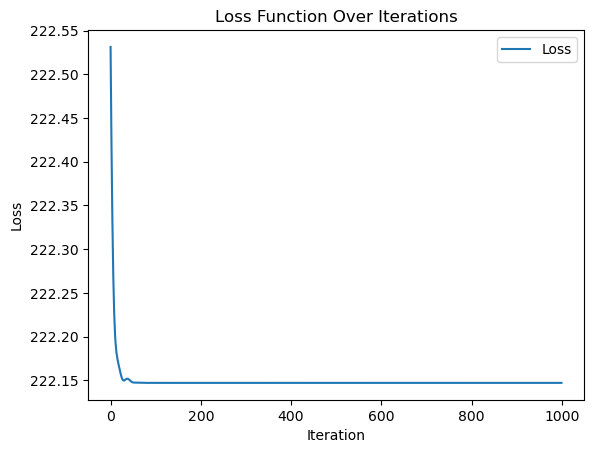

In [130]:
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt, pi, exp

# Cargamos los datos
df = pd.read_csv('poisson_glm_dataset.csv')
X = df.iloc[:, :3].to_numpy()
y = df['y'].to_numpy()

# Convertimos el vector de variables independientes y la variable dependiente en un Tensor de TensorFlow.
X_tf = tf.constant(X, dtype=tf.float32)
y_tf = tf.constant(y, dtype=tf.float32)

# Generate a synthetic binary classification dataset
n_samples = X.shape[0]
n_features = X.shape[1]


# Initialize model parameters (beta coefficients) 
#beta = tf.Variable(tf.random.normal([n_features+1, 1], dtype=tf.float32))
beta = tf.Variable([-0.03, 0.50, -0.25, 0.75], dtype=tf.float32)
beta = tf.Variable(tf.reshape(beta, [4, 1])) 


def loss_fn(X, y, beta):
    
    #Calculamos el valor de y_pred.
    valor_uno = tf.ones((X.shape[0], 1), dtype=tf.float32)  # Crea una columna de 1s en TensorFlow
    X1_tf = tf.concat([valor_uno, X], axis=1)
    
    y_pred = tf.exp(tf.matmul(X1_tf, beta))
    
    #Reshape de los tensores.
    y_pred = tf.reshape(y_pred, (y_pred.shape[0],1))
    y = tf.reshape(y, (y_pred.shape[0],y_pred.shape[1]))

    loss = y_pred-y*tf.math.log(y_pred+10**(-5))
    return  tf.reduce_sum(loss)

# Inicializamos la lista para almacenar la función de pérdida. 
loss_values = []

# Optimizer (Stochastic Gradient Descent)

# SGD
#optimizer = tf.optimizers.SGD(learning_rate=12.0)

# Nesterov
# optimizer = tf.optimizers.SGD(learning_rate=0.01, nesterov=True)

# Adagrad
# optimizer = tf.optimizers.Adagrad(learning_rate=0.01)

# RMSProp
#optimizer = tf.optimizers.RMSprop(learning_rate=0.01)

# Adam
optimizer = tf.optimizers.Adam(learning_rate=0.001)

# Training the logistic regression model
num_epochs = 1000
for epoch in range(num_epochs):
    # Compute current loss and gradient
    with tf.GradientTape() as tape:
        loss = loss_fn(X_tf, y_tf, beta)
    gradients = tape.gradient(loss, [beta])
    optimizer.apply_gradients(zip(gradients, [beta]))



    # Store the loss values for the graph
    loss_values.append(loss.numpy())
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy():.4f}")

# Print final model coefficients (beta)
print(f"Final model coefficients (beta): {beta.numpy().flatten()}")

plt.figure()
# Plot the loss function values over iterations
plt.plot(range(num_epochs), loss_values, label="Loss")
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Function Over Iterations')
plt.legend()
plt.show()


Creo que, tras la corrección del signo -, he llegado a la solución, aunque me falta tiempo para comprobarlo. Mi procedimiento ha sido probar con un valor de beta inicial aleatorio y, a continuació, en la siguiente prueba, pongo el mejor valor que me ha dado. En base a los valores de la funcion parece que hemos llegado, al menos a un minimo local. (ya que la -verosimilitud no cambia a lo largo de las iteraciones). ()Se ha probado con diversas tasas de aprendizaje, obteniedo lo mismo).
